@author Meghana Kamineni

This a scratch notebook to test out different code for segmentation, but the code to run is stored elsewhere. 
Code for segmentation and voxel density extraction for organs is in stitch_images.sh.

In [2]:
# Import necessary modules
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os

In [124]:
# count how many total images there are
!gsutil ls gs://bulkml4cvd/bodymri/all/raw/** | wc -l

45975


In [146]:
# count how many images of the second instance there are
!gsutil ls gs://bulkml4cvd/bodymri/all/raw/*_2_0.zip | wc -l

43416


In [160]:
# take first counter*1000 with head and then copy the last 1000 in that list
!gsutil ls gs://bulkml4cvd/bodymri/all/raw/*_2_0.zip | head -n 1 | tail -n 1 | gsutil -m cp -I data/

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
Copying gs://bulkml4cvd/bodymri/all/raw/1000107_20201_2_0.zip...
Copying gs://bulkml4cvd/bodymri/all/raw/1000408_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1000169_20201_2_0.zip...
Copying gs://bulkml4cvd/bodymri/all/raw/1000336_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1000387_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1000426_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1000503_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1000795_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1000800_20201_2_0.zip...                
Copying gs://bulkml4cvd/bodymri/all/raw/1001047_20201_2_0.zip...                
\ [10/10 files][693.7 MiB/693.7 MiB] 100% Done                                  
Operation complet

In [161]:
!python extract_ukbb.py --zip_folder data/ --nifti_folder stitched_data/
#This will take all the original data and then stitch it and put the data in stitched_data

/home/jupyter/MRI-spleen/data
2023-02-24 18:36:16,193: Started extract_ukbb...
2023-02-24 18:36:16,193: zip_folder: /home/jupyter/MRI-spleen/data
2023-02-24 18:36:16,193: nifti_folder: /home/jupyter/MRI-spleen/stitched_data
2023-02-24 18:36:16,193: num_subjects: -1
2023-02-24 18:36:16,193: start_idx: 0

2023-02-24 18:36:16,194: Number of subjects will be converted: 10

2023-02-24 18:36:16,194: Stitching tool: /home/jupyter/MRI-spleen/stitching

2023-02-24 18:36:16,194: Already converted subject id [1000107]...

2023-02-24 18:36:16,194: Currently converting subject id [1000169]: /home/jupyter/MRI-spleen/stitched_data/1000169/
2023-02-24 18:36:33,691: Output [T1_in.nii.gz]: b'stitching image...done. took 6487 ms\n'
2023-02-24 18:36:33,691: Error [T1_in.nii.gz]: None
2023-02-24 18:36:40,306: Output [T1_opp.nii.gz]: b'stitching image...done. took 6583 ms\n'
2023-02-24 18:36:40,306: Error [T1_opp.nii.gz]: None
2023-02-24 18:36:46,821: Output [T1_fat.nii.gz]: b'stitching image...done. took 6

In [156]:
#Next we need to change the files so that they are ready for the segmentation model (which is a neural network)
!python convert2nnunet.py --nifti_folder stitched_data/ --nnunet_folder nnunet_data/ --dataset_name ukbb --num_channels 4

usage: convert2nnunet.py [-h] --nifti_folder NIFTI_FOLDER --nnunet_folder
                         NNUNET_FOLDER --dataset_name {ukbb,gnc}
                         --num_channels {1,4} [--num_subjects NUM_SUBJECTS]
                         [--start_idx START_IDX]
convert2nnunet.py: error: unrecognized arguments: -y


In [99]:
#Next we need to do predictions of each part of the image and what organ it belongs to
!CUDA_VISIBLE_DEVICES=0 | RESULTS_FOLDER=models/ | python predict.py --nnunet_folder nnunet_data/ --prediction_folder predictions/ --dataset_name ukbb --num_channels 4

/bin/bash: =models/: No such file or directory
/bin/bash: =0: command not found


Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

nnUNet_raw_data_base is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
RESULTS_FOLDER is not

In [ ]:
!python convert2original.py --prediction_folder predictions/ --output_folder outputs/

In [5]:
# helper functions
def array_from_image(filename):
    # Read the .nii image containing the volume with SimpleITK:
    sitk_t1 = sitk.ReadImage(filename)

    # and access the numpy array:
    t1     = sitk.GetArrayFromImage(sitk_t1)
    return t1

In [36]:
# want to open the segmented image

# A path to a T1-weighted brain .nii image:
t1_fn   = 'outputs/1000107/prd.nii.gz'
t1_fn   = 'stitched_data/1000107/fat.nii.gz'
t1_fn   = 'outputs/1000107/2_wat.nii.gz'
t1_fn   = 'nnunet_data/ukbb_4ch_14435_0002.nii.gz'
t1_fn   = '/home/jupyter/MRI-spleen/nnunet_data/ukbb_4ch_19747_0000.nii.gz'
t1_fn   = '/home/jupyter/MRI-spleen/predictCAD/images/'
# and access the numpy array:
t1     = array_from_image(t1_fn)

HDF5-DIAG: Error detected in HDF5 (1.12.1) thread 0:
  #000: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5Fdeprec.c line 156 in itk_H5Fis_hdf5(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3769 in itk_H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLcallback.c line 3699 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhdf5/src/H5VLnative_file.c line 384 in itk_H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Unable to initialize object
  #004: /tmp/SimpleITK-build/ITK/Modules/ThirdParty/HDF5/src/itkhd

RuntimeError: Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK/Code/IO/src/sitkImageReaderBase.cxx:105:
sitk::ERROR: Unable to determine ImageIO reader for "/home/jupyter/MRI-spleen/predictCAD/images/"

In [8]:
t1.shape

(224, 168, 363)

In [9]:
def get_unique(t1):
    all_unique = set()
    for i in range(t1.shape[2]):
        all_unique = all_unique | set(np.unique(t1[:,:,i]))
    return all_unique
#print(get_unique(t1))
t1[:,:,105]

array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [10]:
transp=np.transpose(np.nonzero(t1))
transp

array([[121,  52, 276],
       [121,  52, 277],
       [121,  52, 278],
       ...,
       [167,  56, 263],
       [167,  57, 263],
       [167,  57, 264]])

In [ ]:
plt.imshow(t1[:,:,200])

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: UserWarning: Attempting to set identical bottom == top == -0.5 results in singular transformations; automatically expanding.
  


array([], shape=(0, 50), dtype=float64)

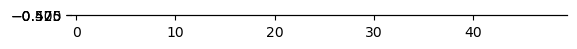

In [15]:
new = t1[240:300,60:110,105]
plt.imshow(new)
import sys
np.set_printoptions(threshold=False)
new
#transp=np.transpose(np.nonzero(new))
#transp
#list(set(i for j in transp for i in j))

In [ ]:
max_rows = 5
max_cols = 50

fig, axes = plt.subplots(nrows=max_rows, ncols=max_cols, figsize=(20,8))
for row in range(max_rows):
    for idx in range(max_cols):
        axes[row, idx].axis("off") 
        #axes[row, idx].set_title('Image'+str(idx+1))
        if row*50+idx-1<224:
            axes[row,idx].imshow(t1[:,:,row*50+idx-1], cmap="gray")

plt.subplots_adjust(wspace=.1, hspace=.1)
#plt.savefig('segmentations.png')
plt.show()

In [ ]:
import imageio
from PIL import Image as im
images = []        #array to store the images
for i in range(t1.shape[2]):
    plt.imshow(t1[:,:,i])
    filename = 'figures/'+str(i)+'.png'
    plt.savefig(filename)
    images.append(imageio.imread(filename))  #reading the images into into images[]
    
imageio.mimsave('movie.gif', images)  #movie making

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  


GET VOXEL DENSITIES BELOW

In [330]:
# go through outputs folder and then go through stitched_data folder
stitched_dir = 'stitched_data'
stitched_ext = 'inp.nii.gz'
directory = 'outputs'
        
def segment_one_org(array, org_label = 5):
    def map_label(i, org_label = org_label):
        if i == org_label:
            return 1
        else:
            return 0
        

    vec_map = np.vectorize(map_label)
    #print(get_unique(array))
    updatedArray = vec_map(array)
    #print(get_unique(updatedArray)) #comment out to check that the vec_map is working
    
    print("Number of pixels for label %d: %d" %(org_label, np.sum(updatedArray)))
    return updatedArray

for subdir, dirs, files in os.walk(directory):
    for file in files:
        if file.endswith('.gz') and stitched_ext not in file:
            print(os.path.join(subdir, file))
            subject_id = subdir.split('/')[1]
            print(subject_id)
            stitched_vol_fn = '/'.join([stitched_dir, subject_id, stitched_ext])
            print(stitched_vol)
            
            segment_map = array_from_image(os.path.join(subdir, file))
            orig_image = array_from_image(stitched_vol_fn)
            segment_map = np.array(segment_map)
            orig_image = np.array(orig_image)
            #print(segment_map.shape)
            #print(orig_image.shape)
            
            for org_label in range(1, 6):
                segment_org = segment_one_org(segment_map, org_label)
                #print(segment_org.shape)
                desired_voxel = np.multiply(segment_org, orig_image)     
                print(desired_voxel.shape)
                #TODO need to save this image as a gz
                final_img = nib.Nifti1Image(desired_voxel.T, affine=np.eye(4))
                nib.save(final_img, os.path.join(directory, subject_id, str(org_label)+'_'+stitched_ext))



outputs/1000107/prd.nii.gz
1000107
stitched_data/1000107/inp.nii.gz
Number of pixels for label 1: 90319
(363, 168, 224)
(168, 224, 363)
Number of pixels for label 2: 11932
(363, 168, 224)
(168, 224, 363)
Number of pixels for label 3: 9573
(363, 168, 224)
(168, 224, 363)
Number of pixels for label 4: 9857
(363, 168, 224)
(168, 224, 363)
Number of pixels for label 5: 6262
(363, 168, 224)
(168, 224, 363)


In [ ]:
# double check functionality of np.multiply

In [295]:
arr = np.array([[[2, 1], [1, 0]], [[2, 6], [1, 3]]])
arr2 = np.array([[[2, 3], [1, 0]], [[2, 1], [1, 3]]])
np.multiply(arr, arr2)      

array([[[4, 3],
        [1, 0]],

       [[4, 6],
        [1, 9]]])